# Comparative Statics in χ — Endowment Economy (Validation + Plots)

Interactive replacement for the former
`scripts/check_comparative_statics_chi.jl`. It sweeps the US-bond
convenience-yield parameter $\chi$ over
$\{0.005, 0.01, 0.02, 0.03\}$ in the **endowment** two-country OLG model
(`TwoCountryOLG.jl`), then:

1. Solves each calibration and summarizes the date-0 portfolio block,
   risk-free rates, exorbitant-privilege spread, and bubble diagnostics.
2. Validates that every run converges and produces non-empty policy
   paths (the smoke-test the original script performed).
3. Plots the comparative-statics paths the validation was protecting:
   $\omega_t$, $\theta_t$, $\theta_{US,t}^*$, and the RoW equity weight
   $1-\omega_t^*$.

This is a companion to `05_comparative_statics.ipynb`; it exists to
guarantee the χ sweep stays solvable as the model evolves.


In [1]:
using Pkg
Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()


  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Plots.GRBackend()

## 1. Solve and Summarize Each χ Calibration

In [2]:
function run_and_summarize(p::ModelParams)
    try
        res = run_simulation(p; verbose=false)
        s0 = res.u_path[1]
        d = res.diagnostics
        return (
            converged = true,
            ω_0 = s0.ω, ω_star_0 = s0.ω_star,
            θ_0 = s0.θ, θ_Us_0 = s0.θ_US_star,
            ω_path = [s.ω for s in res.u_path],
            θ_path = [s.θ for s in res.u_path],
            θ_Us_path = [s.θ_US_star for s in res.u_path],
            ω_RoW_eq_path = [1.0 - s.ω_star for s in res.u_path],
            R_f_0 = s0.R_f, R_f_W_0 = s0.R_f_W,
            ep_0 = s0.R_f - s0.R_f_W,
            Q_US_0 = s0.Q_US, Q_W_0 = s0.Q_W,
            us_share = s0.Q_US / (s0.Q_US + s0.Q_W),
            sum_at = d.sum_a_t[end],
            sum_2a = d.sum_dividend_ratio[end],
            sum_2b = d.sum_cond_2b[end],
            bubble = d.bubble_exists,
            result = res,
        )
    catch err
        @warn "Simulation failed" p err
        return (
            converged = false,
            ω_0 = NaN, ω_star_0 = NaN, θ_0 = NaN, θ_Us_0 = NaN,
            ω_path = Float64[], θ_path = Float64[],
            θ_Us_path = Float64[], ω_RoW_eq_path = Float64[],
            R_f_0 = NaN, R_f_W_0 = NaN, ep_0 = NaN,
            Q_US_0 = NaN, Q_W_0 = NaN, us_share = NaN,
            sum_at = NaN, sum_2a = NaN, sum_2b = NaN,
            bubble = false, result = nothing,
        )
    end
end

θ_path_of(r) = hasproperty(r, :θ_path) ? r.θ_path : [s.θ for s in r.result.u_path]

function check_result(r, plot_periods)
    path_lengths = (
        ω = length(r.ω_path),
        θ = length(θ_path_of(r)),
        θ_Us = length(r.θ_Us_path),
        ω_RoW_eq = length(r.ω_RoW_eq_path),
    )
    minimum(values(path_lengths)) > 0 || error("One or more plotted paths are empty")
    for (name, len) in pairs(path_lengths)
        n_plot = min(plot_periods, len)
        n_plot > 0 || error("Plot horizon for $(name) is empty")
    end
    isfinite(r.R_f_0) || error("R_f_0 is not finite")
    isfinite(r.ep_0) || error("ep_0 is not finite")
    isfinite(r.sum_at) || error("sum_at is not finite")
    return path_lengths
end


check_result (generic function with 1 method)

In [3]:
plot_periods = 50
chi_vals = [0.005, 0.01, 0.02, 0.03]

println("Running χ comparative-statics validation with plot_periods=$(plot_periods)")
chi_results = [run_and_summarize(ModelParams(χ=v)) for v in chi_vals]
converged = Tuple{Float64, Any}[]
failed = Float64[]

for (v, r) in zip(chi_vals, chi_results)
    if !r.converged
        push!(failed, v)
        println("χ=$(v): converged=false")
        continue
    end
    lengths = check_result(r, plot_periods)
    push!(converged, (v, r))
    println(
        "χ=$(v): converged=$(r.converged), ",
        "R_f=$(round(r.R_f_0, digits=4)), ",
        "EP=$(round(r.ep_0, digits=4)), ",
        "θ0=$(round(r.θ_0, digits=6)), ",
        "path_lengths=$(lengths)",
    )
end

isempty(converged) && error("No χ runs converged; path plots would be empty")
if !isempty(failed)
    println("non-converged χ values: ", failed)
end
println("\n✓ chi comparative-statics check passed")


Running χ comparative-statics validation with plot_periods=50
χ=0.005: converged=true, R_f=1.0833, 

EP=-0.0641, θ0=-1.602578, path_lengths=(ω = 120, θ = 120, θ_Us = 120, ω_RoW_eq = 120)
χ=0.01: converged=true, R_f=1.0632, EP=-0.086, θ0=-2.380544, path_lengths=(ω = 120, θ = 120, θ_Us = 120, ω_RoW_eq = 120)
χ=0.02: converged=true, R_f=1.0298, EP=-0.1211, θ0=-3.353148, path_lengths=(ω = 120, θ = 120, θ_Us = 120, ω_RoW_eq = 120)
χ=0.03: converged=true, R_f=0.9995, EP=-0.1525, θ0=-3.959983, path_lengths=(ω = 120, θ = 120, θ_Us = 120, ω_RoW_eq = 120)

✓ chi comparative-statics check passed


## 2. Summary Table at Date 0

In [4]:
println("  χ       ω_0     ω*_0    θ_0        θ_US*_0    R_f      R_f^W    EP        US-share  bubble")
for (v, r) in converged
    @printf("  %.3f   %.4f  %.4f  %+.6f  %+.6f  %.4f  %.4f  %+.5f  %.4f    %s\n",
            v, r.ω_0, r.ω_star_0, r.θ_0, r.θ_Us_0, r.R_f_0, r.R_f_W_0,
            r.ep_0, r.us_share, r.bubble)
end


  χ       ω_0     ω*_0    θ_0        θ_US*_0    R_f      R_f^W    EP        US-share  bubble
  0.005   0.6345  0.1469  -1.602578  +0.177183  1.0833  1.1474  -0.06412  0.2733    false
  0.010   0.5848  0.1486  -2.380544  +0.261912  1.0632  1.1492  -0.08604  0.2948    false


  0.020   0.5413  0.1520  -3.353148  +0.365407  1.0298  1.1510  -0.12115  0.3185    false
  0.030   0.5281  0.1542  -3.959983  +0.427545  0.9995  1.1521  -0.15252  0.3349    false


## 3. Comparative-Statics Paths Across χ

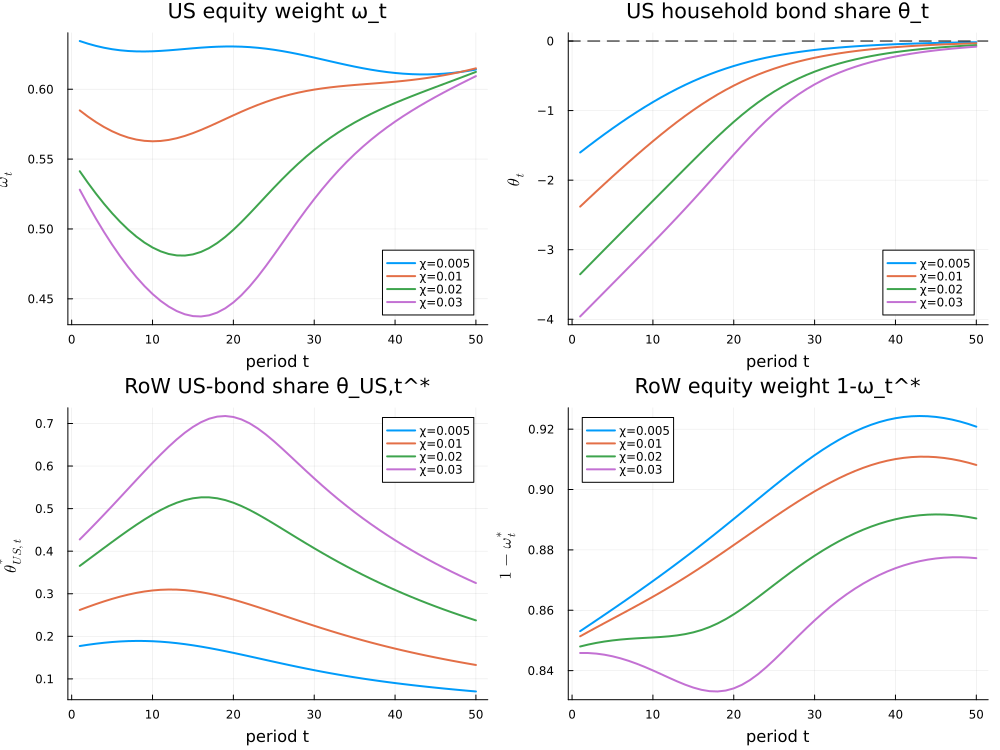

In [5]:
npath = minimum(min(plot_periods, length(r.ω_path)) for (_, r) in converged)
tt = 1:npath

p1 = plot(xlabel="period t", ylabel=L"\omega_t", title="US equity weight ω_t")
for (v, r) in converged
    plot!(p1, tt, r.ω_path[1:npath], lw=2, label="χ=$v")
end

p2 = plot(xlabel="period t", ylabel=L"\theta_t", title="US household bond share θ_t")
for (v, r) in converged
    plot!(p2, tt, θ_path_of(r)[1:npath], lw=2, label="χ=$v")
end
hline!(p2, [0.0], ls=:dash, color=:black, label="")

p3 = plot(xlabel="period t", ylabel=L"\theta_{US,t}^*", title="RoW US-bond share θ_US,t^*")
for (v, r) in converged
    plot!(p3, tt, r.θ_Us_path[1:npath], lw=2, label="χ=$v")
end

p4 = plot(xlabel="period t", ylabel=L"1-\omega_t^*", title="RoW equity weight 1-ω_t^*")
for (v, r) in converged
    plot!(p4, tt, r.ω_RoW_eq_path[1:npath], lw=2, label="χ=$v")
end

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## Summary

- Replaces `scripts/check_comparative_statics_chi.jl`: sweeps
  $\chi \in \{0.005, 0.01, 0.02, 0.03\}$ in the endowment economy
  (`TwoCountryOLG.jl`), asserts every run converges with non-empty
  policy paths, and reports the date-0 portfolio/return block.
- The interactive version additionally plots the $\omega, \theta,
  \theta_{US}^*, 1-\omega^*$ paths the validation was protecting.
- Raising $\chi$ strengthens the US-bond convenience yield, widening
  the exorbitant-privilege spread $R_f^W - R_f$ and shifting RoW bond
  demand $\theta_{US}^*$.
